In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import os
os.chdir("/content/drive/MyDrive/DO_AN_DS_KI_1_NAM_3/DS201/NLe/KG-building")
# os.chdir("/content/drive/MyDrive/KG-building")

## Set up environment

In [3]:
%%capture
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install transformers
!pip install bert-score
!pip install py_vncorenlp
!pip install matplotlib tqdm pandas numpy

## Check up modules

### Config

In [ ]:
from model_module.config import Config

config = Config()
print(config)
print("\n Config loaded successfully!")

Model Configuration:
device                   : cuda
kg_triples_path          : knowledge_graph_triples.csv
neo4j_nodes_path         : neo4j_nodes.csv
neo4j_rels_path          : neo4j_relationships.csv
qa_dataset_path          : 6000_samples.csv
kg_min_confidence        : 0.95
kg_max_hops              : 2
kg_emb_dim               : 300
tokenizer_type           : vihealthbert_vncorenlp
vocab_size               : 5000
max_seq_len              : 128
vihealthbert_model       : demdecuong/vihealthbert-base-word
use_vncorenlp            : True
vncorenlp_path           : ./vncorenlp
d_model                  : 256
num_heads                : 8
num_layers               : 3
d_ff                     : 1024
gnn_hidden               : 256
gnn_type                 : gcn
gnn_layers               : 2
dropout                  : 0.1
batch_size               : 8
num_epochs               : 10
learning_rate            : 0.0001
weight_decay             : 0.01
grad_clip_norm           : 1.0
train_ratio       

### Load data

In [ ]:
from model_module.data_loader import (
    load_knowledge_graph_data,
    load_qa_dataset,
    print_qa_examples
)

kg_triples, neo4j_nodes, neo4j_rels = load_knowledge_graph_data(
    config.kg_triples_path,
    config.neo4j_nodes_path,
    config.neo4j_rels_path
)


print("\nSample KG triples:")
print(kg_triples.head(3))

print("\nSample nodes:")
print(neo4j_nodes.head(3))

print("\nSample relationships:")
print(neo4j_rels.head(3))

Loading Knowledge Graph data...
KG Triples: 30,955 triples
Nodes: 4,525 nodes
Relationships: 30,955 relationships

Statistics:
  Unique entities: 4,525
  Unique relations: 5

Sample KG triples:
              subject    predicate              object
0          VIÊM GAN B  HAS_SYMPTOM   TRÀO NGƯỢC DẠ DÀY
1          VIÊM GAN B  HAS_SYMPTOM  XUNG HUYẾT HANG VỊ
2  XUNG HUYẾT HANG VỊ  HAS_SYMPTOM   TRÀO NGƯỢC DẠ DÀY

Sample nodes:
              name:ID         :LABEL
0          VIÊM GAN B  DISEASESYMTOM
1  XUNG HUYẾT HANG VỊ  DISEASESYMTOM
2        CAO HUYẾT ÁP  DISEASESYMTOM

Sample relationships:
            :START_ID        :TYPE             :END_ID  confidence
0          VIÊM GAN B  HAS_SYMPTOM   TRÀO NGƯỢC DẠ DÀY    0.999892
1          VIÊM GAN B  HAS_SYMPTOM  XUNG HUYẾT HANG VỊ    0.999892
2  XUNG HUYẾT HANG VỊ  HAS_SYMPTOM   TRÀO NGƯỢC DẠ DÀY    0.999892


In [ ]:
qa_dataset = load_qa_dataset(config.qa_dataset_path)
print_qa_examples(qa_dataset, num_examples=3)

print("\n QA dataset loaded!")

print("\nFirst sample structure:")
sample = qa_dataset[0]
for key, value in sample.items():
    print(f"  {key}: {type(value)} = {value if not isinstance(value, (list, str)) or len(str(value)) < 50 else str(value)[:50]+'...'}")


Loading real QA dataset from 6000_samples.csv...
Dataset loaded: 6,379 samples
Columns: ['qa_id', 'question', 'entity_count', 'unique_entity_types', 'entity_types', 'entities', 'is_multihop', 'reasons', 'rule_based', 'answer', 'context_text', 'context_title', 'context_url', 'keyword', 'topic', 'entities_question', 'entities_answer', 'entities_context']

Multi-hop distribution:
is_multihop
True    6379
Name: count, dtype: int64

Processing dataset...


Processing QA: 100%|██████████| 6379/6379 [00:01<00:00, 5684.85it/s]


Processed 6,379 valid QA pairs
  - Single-hop: 0
  - Multi-hop: 6,379

Example QA pairs:

--- Example 1 (2-hop) ---
ID: qa_4
Question: Vừa qua ngày 4/6 tôi có bị con chó ở nhà cắn xước ngoài da và tôi đã đến trung tâm y tế để tiêm ngừa...
Answer: Bệnh dại là bệnh nguy hiểm và nếu có chỉ định tiêm phòng vaccine thì cần được ưu...
Entities (9): ['xước', 'tiê', 'tiêm', 'ngừa', 'vaccine']

--- Example 2 (2-hop) ---
ID: qa_7
Question: Mệt mỏi, ngạt mũi có phải triệu chứng bệnh viêm đường hô hấp không?...
Answer: Các triệu chứng bạn liệt kê ở trên hoàn toàn có thể là những dấu hiệu ban đầu củ...
Entities (5): ['Mệt mỏi', 'ngạt mũi', 'triệu chứng', 'viêm', 'đường hô hấp']

--- Example 3 (2-hop) ---
ID: qa_11
Question: Em đang điều trị ARV được 3 năm và CD4 ổn định ~500 (theo em hiểu đây cũng được xếp vào bệnh nền), t...
Answer: Đúng là một số bệnh lý tim mạch, hô hấp. . . mãn tính mà điều trị ổn định có thể...
Entities (5): ['điều trị', 'bệnh nền', 'tiêm', 'vaccine', 'Covid']

 QA dataset lo

### Knowledge Graph

In [ ]:
from model_module.knowledge_graph import MedicalKnowledgeGraph


medical_kg = MedicalKnowledgeGraph(
    neo4j_rels,
    min_confidence=config.kg_min_confidence
)

print(f'\n{medical_kg}')
print("\nMedical KG initialized!")


MedicalKnowledgeGraph(nodes=4525, edges=30955, relations=5)

Medical KG initialized!


In [ ]:
test_entities = qa_dataset[0]['entities'][:3]
print(f"Test entities: {test_entities}")

subgraph_entities, subgraph_edges = medical_kg.get_subgraph(test_entities, max_hops=2)
print(f"\nSubgraph entities ({len(subgraph_entities)}): {subgraph_entities[:5]}")
print(f"Subgraph edges: {len(subgraph_edges)} edges")

# Convert to PyG format
node_features, edge_index, entity_list = medical_kg.get_pyg_data(
    entities=test_entities,
    use_pretrained_emb=False,
    emb_dim=config.kg_emb_dim
)

print(f"\nPyG Format:")
print(f"  node_features.shape: {node_features.shape}")
print(f"  edge_index.shape: {edge_index.shape}")
print(f"  entity_list length: {len(entity_list)}")

print("\nKG operations working!")

Test entities: ['xước', 'tiê', 'tiêm']

Subgraph entities (3): ['tiê', 'tiêm', 'xước']
Subgraph edges: 0 edges

PyG Format:
  node_features.shape: torch.Size([3, 300])
  edge_index.shape: torch.Size([2, 0])
  entity_list length: 3

KG operations working!


In [ ]:
# # Download VnCoreNLP
# !mkdir -p vncorenlp
# !cd vncorenlp && wget -q https://github.com/vncorenlp/VnCoreNLP/raw/master/VnCoreNLP-1.2.jar
# !ls -lh vncorenlp/
# !cd vncorenlp && wget https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
# !cd vncorenlp && unzip -q master.zip
# !cd vncorenlp && mv VnCoreNLP-master/* .
# !ls -la vncorenlp/
# Install vncorenlp package
!pip install vncorenlp

print("\n VnCoreNLP setup completed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 43.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=6ceffac81682d79c586e1e3adf80814b6f3db3099f5bb55860c9ce430937c964
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp

 VnCoreNLP setup completed!


In [ ]:
# Reload module để áp dụng changes
import importlib
import sys

from model_module.vihealthbert_tokenizer import ViHealthBERTTokenizer

tokenizer = ViHealthBERTTokenizer(
    model_name='demdecuong/vihealthbert-base-word',
    max_len=128,
    use_vncorenlp=True,
    vncorenlp_path='vncorenlp'
)

# Test
text = "Ông Nguyễn Văn A bị viêm gan B"
print(f"\nOriginal:   {text}")

segmented = tokenizer.word_segment(text)
print(f"Segmented:  {segmented}")

encoded = tokenizer.encode(text)
print(f"Encoded:    {encoded[:15]}...")

decoded = tokenizer.decode(encoded)
print(f"Decoded:    {decoded}")

# Check status
print(f"\nTokenizer status:")
print(f"  VnCoreNLP enabled: {tokenizer.use_vncorenlp}")
print(f"  VnCoreNLP object: {tokenizer.vncorenlp is not None}")

print("\n" + "="*70)
if tokenizer.use_vncorenlp and '_' in segmented:
    print("VnCoreNLP WORKING! Word segmentation successful!")
else:
    print("VnCoreNLP still not working")
print("="*70)

Initializing ViHealthBERT tokenizer: demdecuong/vihealthbert-base-word


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

✓ VnCoreNLP loaded from vncorenlp/VnCoreNLP-1.2.jar
✓ ViHealthBERT tokenizer initialized
  Model: demdecuong/vihealthbert-base-word
  Vocab size: 64001
  Max length: 128
  VnCoreNLP: Enabled

Original:   Ông Nguyễn Văn A bị viêm gan B
Segmented:  Ông Nguyễn_Văn_A bị viêm gan B
Encoded:    [0, 168, 1649, 768, 45, 1743, 2161, 1247, 2, 1, 1, 1, 1, 1, 1]...
Decoded:    Ông Nguyễn Văn A bị viêm gan B

Tokenizer status:
  VnCoreNLP enabled: True
  VnCoreNLP object: True

VnCoreNLP WORKING! Word segmentation successful!


### Dataset

In [ ]:
from model_module.dataset import KGQADataset, collate_fn
from torch.utils.data import DataLoader

# Create small dataset for testing
test_qa = qa_dataset[:10]

dataset = KGQADataset(
    qa_data=test_qa,
    kg=medical_kg,
    tokenizer=tokenizer,
    kg_emb_dim=config.kg_emb_dim
)

print(f"Dataset size: {len(dataset)}")

# Test __getitem__
sample = dataset[0]
print("\nSample structure:")
for key, value in sample.items():
    if hasattr(value, 'shape'):
        print(f"  {key}: {value.shape}")
    else:
        print(f"  {key}: {type(value)}")

print("\nDataset working!")

Dataset size: 10

Sample structure:
  question_ids: torch.Size([128])
  context_ids: torch.Size([128])
  answer_ids: torch.Size([128])
  kg_node_features: torch.Size([9, 300])
  kg_edge_index: torch.Size([2, 0])
  answer_text: <class 'str'>

Dataset working!


In [ ]:
dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

# Get one batch
batch = next(iter(dataloader))

print("Batch structure:")
for key, value in batch.items():
    if hasattr(value, 'shape'):
        print(f"  {key}: {value.shape}")
    elif isinstance(value, list) and len(value) > 0 and hasattr(value[0], 'x'):
        print(f"  {key}: List of {len(value)} PyG Data objects")
        print(f"    First object: x={value[0].x.shape}, edge_index={value[0].edge_index.shape}")
    else:
        print(f"  {key}: {type(value)}")

print("\nDataLoader working!")

Batch structure:
  question_ids: torch.Size([2, 128])
  context_ids: torch.Size([2, 128])
  answer_ids: torch.Size([2, 128])
  kg_node_features: torch.Size([2, 9, 300])
  kg_edge_index: <class 'list'>
  answer_texts: <class 'list'>

DataLoader working!


### Model

In [ ]:
from model_module.models import (
    PositionalEncoding,
    TextEmbedding,
    GNNEncoder,
    CrossAttention,
    TransformerBlock,
    KGEnhancedTransformer
)
import torch

model = KGEnhancedTransformer(
    vocab_size=len(tokenizer),
    d_model=config.d_model,
    num_heads=config.num_heads,
    num_layers=config.num_layers,
    d_ff=config.d_ff,
    kg_node_features=config.kg_emb_dim,
    gnn_hidden=config.gnn_hidden,
    gnn_type=config.gnn_type,
    gnn_layers=config.gnn_layers,
    dropout=config.dropout,
    output_size=len(tokenizer)
)

model = model.to(config.device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: {total_params * 4 / 1024 / 1024:.2f} MB")

print("\nModel initialized!")


Model Statistics:
  Total parameters: 35,872,513
  Trainable parameters: 35,872,513
  Model size: 136.84 MB

Model initialized!


In [ ]:
print("="*70)
print("TEST 6.2: Model Forward Pass")
print("="*70)

# Get one batch
batch = next(iter(dataloader))

# Move to device - CORRECTED for kg_edge_index
question_ids = batch['question_ids'].to(config.device)
context_ids = batch['context_ids'].to(config.device)
kg_node_features = batch['kg_node_features'].to(config.device)

# Move each edge_index tensor to device
kg_edge_index = [edge_idx.to(config.device) for edge_idx in batch['kg_edge_index']]

answer_ids = batch['answer_ids'].to(config.device)

print(f"Question shape: {question_ids.shape}")
print(f"Context shape: {context_ids.shape}")
print(f"Answer shape: {answer_ids.shape}")
print(f"KG node features shape: {kg_node_features.shape}")
print(f"KG edge_index: {len(kg_edge_index)} graphs")

# Forward pass
model.eval()
with torch.no_grad():
    output = model(
        question_ids=question_ids,
        context_ids=context_ids,
        kg_node_features=kg_node_features,
        kg_edge_index=kg_edge_index
    )

print(f"\nOutput shape: {output.shape}")
print(f"Expected: [batch_size={question_ids.size(0)}, seq_len={question_ids.size(1) + context_ids.size(1)}, vocab_size={len(tokenizer)}]")

# Check output
logits = output  # [batch, seq_len, vocab_size]
predictions = torch.argmax(logits, dim=-1)  # [batch, seq_len]
print(f"Predictions shape: {predictions.shape}")

print("\n Forward pass successful!")

TEST 6.2: Model Forward Pass
Question shape: torch.Size([2, 128])
Context shape: torch.Size([2, 128])
Answer shape: torch.Size([2, 128])
KG node features shape: torch.Size([2, 9, 300])
KG edge_index: 2 graphs

Output shape: torch.Size([2, 256, 64001])
Expected: [batch_size=2, seq_len=256, vocab_size=64001]
Predictions shape: torch.Size([2, 256])

 Forward pass successful!


In [ ]:
# Cell 13: Test train.py functions

from model_module.train import train_epoch, evaluate
import torch.nn as nn
import torch.optim as optim

# Setup for training
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 0 is PAD token
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

# Create train/val split
train_size = int(0.8 * len(qa_dataset))
train_qa = qa_dataset[:train_size]
val_qa = qa_dataset[train_size:train_size+20]  # Small val set for testing

train_dataset = KGQADataset(train_qa[:20], medical_kg, tokenizer, config.kg_emb_dim)
val_dataset = KGQADataset(val_qa[:10], medical_kg, tokenizer, config.kg_emb_dim)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

print("\nTraining setup ready!")

Train samples: 20
Val samples: 10

Training setup ready!


In [ ]:
# Unpack both loss and accuracy
train_loss, train_acc = train_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    config.device
)

print(f"\nTrain Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_acc:.2f}%")

# Evaluate - Also returns (loss, accuracy)
val_loss, val_acc = evaluate(
    model,
    val_loader,
    criterion,
    config.device
)

print(f"\nVal Loss: {val_loss:.4f}")
print(f"Val Accuracy: {val_acc:.2f}%")

print("\nTraining functions working!")

Training: 100%|██████████| 10/10 [00:01<00:00,  6.68it/s, loss=3.8059, acc=81.50%]



Train Loss: 3.9002
Train Accuracy: 83.03%


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 11.38it/s]


Val Loss: 2.5805
Val Accuracy: 87.17%

Training functions working!


### Metrics

In [ ]:
from model_module.metrics import (
    exact_match_score,
    f1_score,
    bleu_score,
    rouge_l_score,
    evaluate_qa_metrics
)

# Test với câu tiếng Việt
prediction = "Triệu chứng của bệnh viêm gan B là sốt cao và mệt mỏi"
ground_truth = "Triệu chứng bệnh viêm gan B gồm sốt, mệt mỏi, vàng da"

print(f"Prediction:    {prediction}")
print(f"Ground Truth:  {ground_truth}")
print()

# Tính từng metric
em = exact_match_score(prediction, ground_truth)
f1 = f1_score(prediction, ground_truth)
bleu = bleu_score(prediction, ground_truth)
rouge = rouge_l_score(prediction, ground_truth)

print(f"Exact Match:   {em:.4f} ({em*100:.2f}%)")
print(f"F1 Score:      {f1:.4f} ({f1*100:.2f}%)")
print(f"BLEU Score:    {bleu:.4f} ({bleu*100:.2f}%)")
print(f"ROUGE-L:       {rouge:.4f} ({rouge*100:.2f}%)")

# Test batch evaluation
print("\n" + "="*70)
print("Batch Evaluation Test")
print("="*70)

predictions = [
    "Bệnh tiểu đường type 2",
    "Paracetamol giúp giảm đau và hạ sốt",
    "Không biết"
]

ground_truths = [
    "Bệnh tiểu đường type 2 là bệnh mạn tính",
    "Paracetamol có tác dụng giảm đau hạ sốt",
    "Không rõ"
]

batch_metrics = evaluate_qa_metrics(predictions, ground_truths)

for metric_name, score in batch_metrics.items():
    print(f"{metric_name:15s}: {score:6.2f}%")

print("\nMetrics module working!")

Prediction:    Triệu chứng của bệnh viêm gan B là sốt cao và mệt mỏi
Ground Truth:  Triệu chứng bệnh viêm gan B gồm sốt, mệt mỏi, vàng da

Exact Match:   0.0000 (0.00%)
F1 Score:      0.7200 (72.00%)
BLEU Score:    0.5371 (53.71%)
ROUGE-L:       0.7200 (72.00%)

Batch Evaluation Test
exact_match    :   0.00%
f1             :  62.70%
bleu           :  49.60%
rouge_l        :  62.70%

Metrics module working!


### Visualization


Plotting training loss...


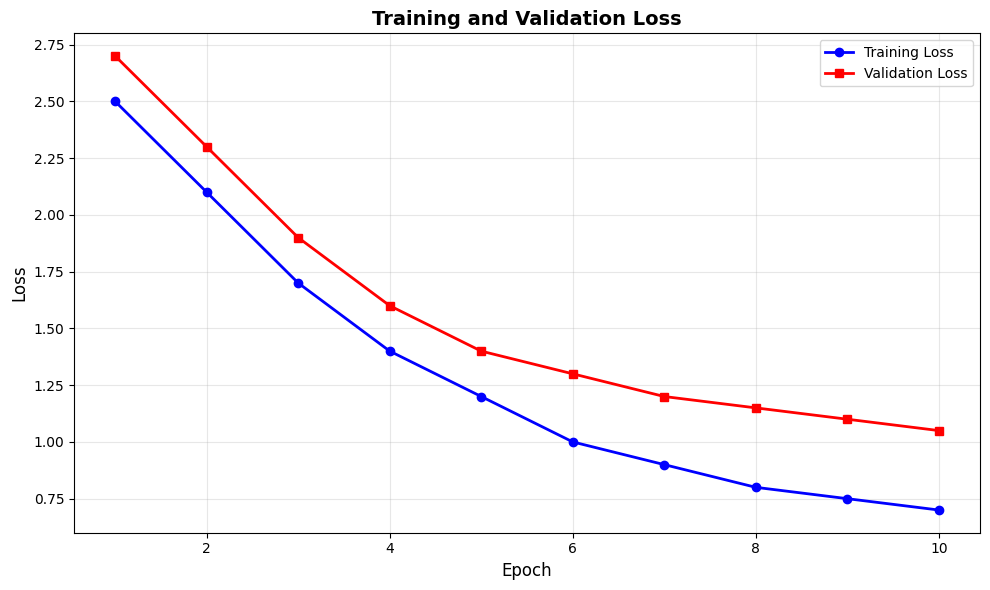


Plotting accuracy and perplexity...


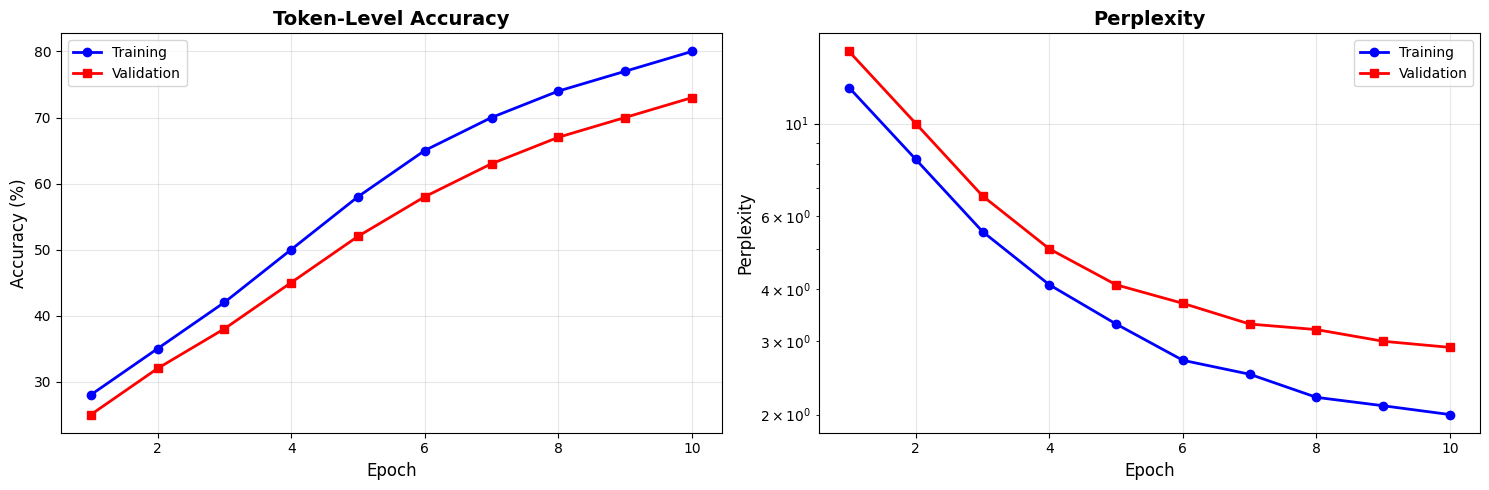


Training history plots created!


In [ ]:
from model_module.visualization import (
    plot_training_history,
    plot_metrics_history,
    print_metrics_table
)
import matplotlib.pyplot as plt

# Mock training history data (giả lập như đã train)
history = {
    'train_loss': [2.5, 2.1, 1.7, 1.4, 1.2, 1.0, 0.9, 0.8, 0.75, 0.7],
    'val_loss': [2.7, 2.3, 1.9, 1.6, 1.4, 1.3, 1.2, 1.15, 1.1, 1.05],
    'train_acc': [28, 35, 42, 50, 58, 65, 70, 74, 77, 80],
    'val_acc': [25, 32, 38, 45, 52, 58, 63, 67, 70, 73],
    'train_ppl': [12.2, 8.2, 5.5, 4.1, 3.3, 2.7, 2.5, 2.2, 2.1, 2.0],
    'val_ppl': [14.9, 10.0, 6.7, 5.0, 4.1, 3.7, 3.3, 3.2, 3.0, 2.9]
}

# Plot 1: Loss over epochs
print("\nPlotting training loss...")
plot_training_history(history)

# Plot 2: Accuracy and Perplexity
print("\nPlotting accuracy and perplexity...")
plot_metrics_history(history)

print("\nTraining history plots created!")


                   QA Evaluation Metrics                    
exact_match :  45.5000
f1          :  62.3000
bleu        :  38.7000
rouge_l     :  55.2000


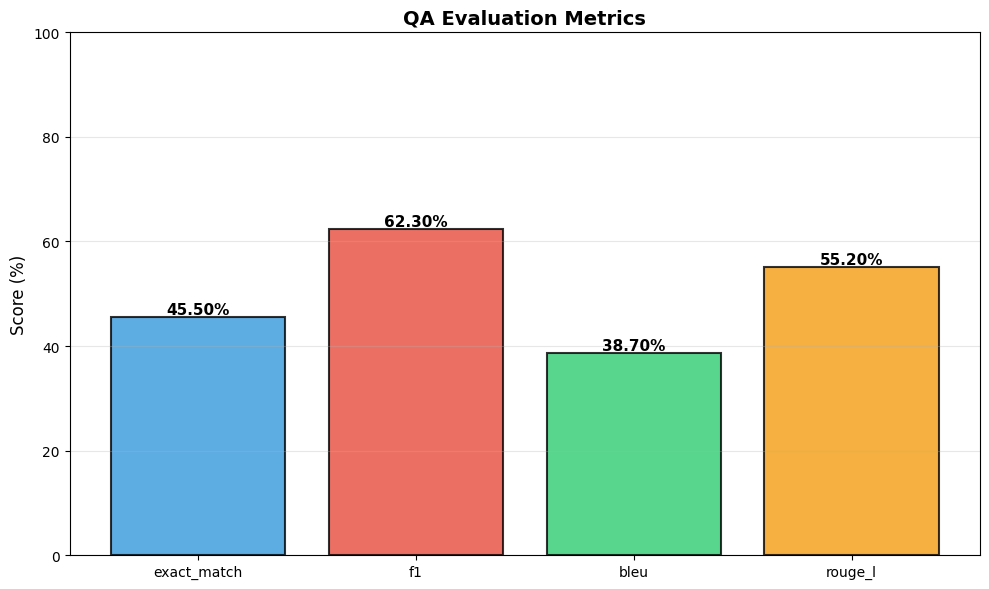


QA metrics visualization working!


In [ ]:
from model_module.visualization import plot_qa_metrics, print_metrics_table

# Mock QA metrics
qa_metrics = {
    'exact_match': 45.5,
    'f1': 62.3,
    'bleu': 38.7,
    'rouge_l': 55.2
}

# Print as table
print_metrics_table(qa_metrics, title="QA Evaluation Metrics")

# Plot bar chart
plot_qa_metrics(qa_metrics)

print("\nQA metrics visualization working!")

✓ Complete summary saved to test_complete_summary.png


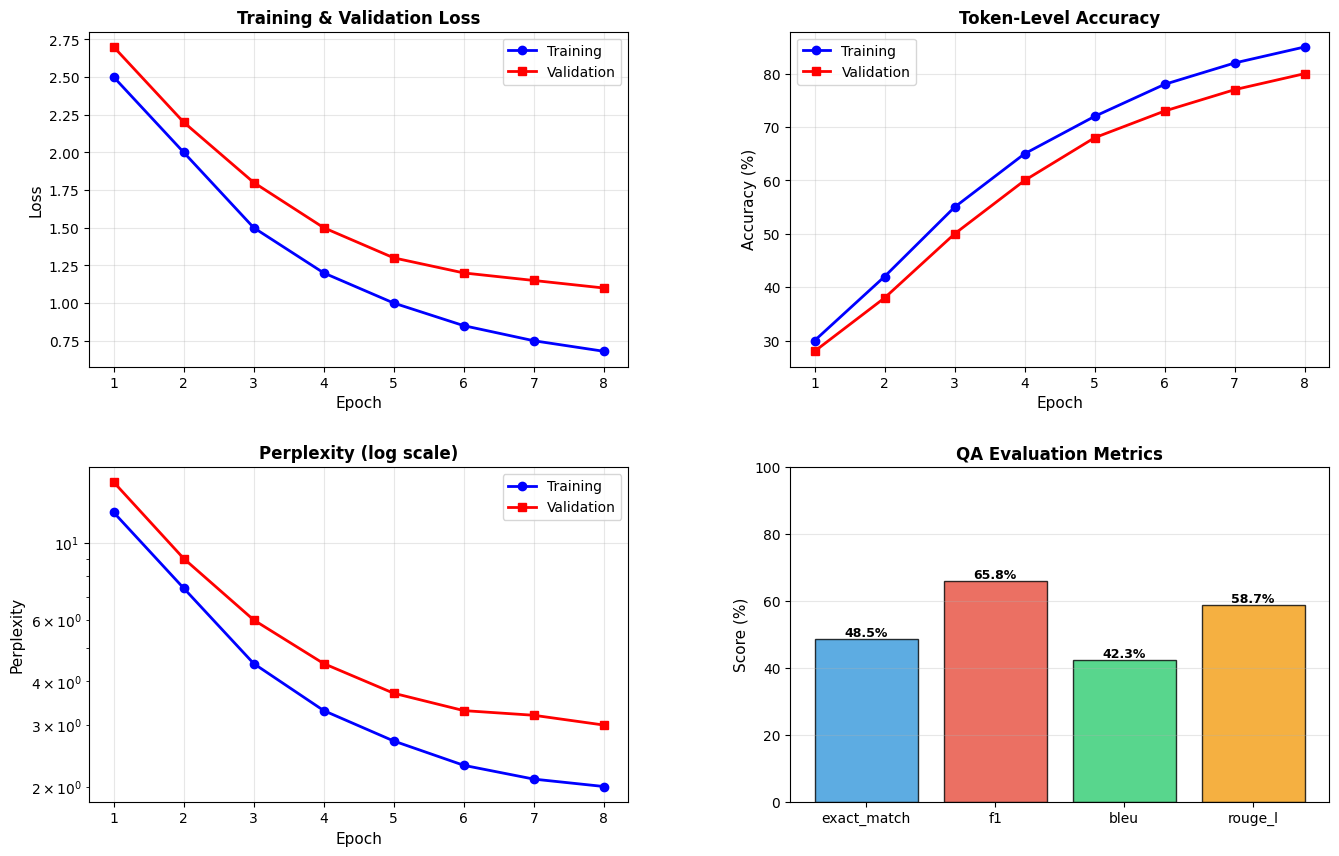


Complete summary created and saved!


In [ ]:
from model_module.visualization import plot_complete_summary

# Tạo summary với cả training history và QA metrics
history = {
    'train_loss': [2.5, 2.0, 1.5, 1.2, 1.0, 0.85, 0.75, 0.68],
    'val_loss': [2.7, 2.2, 1.8, 1.5, 1.3, 1.2, 1.15, 1.1],
    'train_acc': [30, 42, 55, 65, 72, 78, 82, 85],
    'val_acc': [28, 38, 50, 60, 68, 73, 77, 80],
    'train_ppl': [12.2, 7.4, 4.5, 3.3, 2.7, 2.3, 2.1, 2.0],
    'val_ppl': [14.9, 9.0, 6.0, 4.5, 3.7, 3.3, 3.2, 3.0]
}

qa_metrics = {
    'exact_match': 48.5,
    'f1': 65.8,
    'bleu': 42.3,
    'rouge_l': 58.7
}

# Plot everything in one figure
plot_complete_summary(history, qa_metrics, save_path='test_complete_summary.png')

print("\nComplete summary created and saved!")

### Inference

In [ ]:
del sys.modules["model_module.inference"]

In [ ]:
from model_module.inference import predict
import torch

# Đảm bảo model ở eval mode
model.eval()

# Lấy 1 sample từ validation set
test_sample = val_qa[0]

print(f"Question: {test_sample['question']}")
print(f"Entities: {test_sample['entities'][:5]}...")
print(f"True Answer: {test_sample['answers'][0][:80]}...")
print("\nPredicting...")

# Predict
try:
    predicted_answer = predict(
        model=model,
        question=test_sample['question'],
        context=test_sample['context'],
        entities=test_sample['entities'],
        kg=medical_kg,
        tokenizer=tokenizer,
        device=config.device,
        max_len=50
    )

    print(f"\nPredicted Answer: {predicted_answer}")

    # Calculate metrics for this prediction
    from model_module.metrics import exact_match_score, f1_score, bleu_score

    em = exact_match_score(predicted_answer, test_sample['answers'][0])
    f1 = f1_score(predicted_answer, test_sample['answers'][0])
    bleu = bleu_score(predicted_answer, test_sample['answers'][0])

    print(f"\nMetrics:")
    print(f"  Exact Match: {em:.4f}")
    print(f"  F1 Score:    {f1:.4f}")
    print(f"  BLEU Score:  {bleu:.4f}")

    print("\nSingle prediction successful!")

except Exception as e:
    print(f"Error during prediction: {e}")
    import traceback
    traceback.print_exc()

Question: Hàng rào máu não có vai trò gì trong việc ngăn ngừa viêm màng não?
Entities: ['Hàng rào máu', 'não', 'ngăn ngừa', 'viêm màng não']...
True Answer: Hàng rào máu não giúp bảo vệ não không bị nhiễm trùng bằng cách ngăn cản vi khuẩ...

Predicting...

Predicted Answer: 

Metrics:
  Exact Match: 0.0000
  F1 Score:    0.0000
  BLEU Score:  0.0000

Single prediction successful!


## Main

### train

In [ ]:
modules = ["__init__", "config", "data_loader", "dataset", "inference", "knowledge_graph", "main", "metrics", "models", "train", "vit5_tokenizer", "visualization"]
my_modules = ["model_module." + module for module in modules]
import sys
for module_name in my_modules:
    if module_name in sys.modules:
        del sys.modules[module_name]

Model Configuration:
device                   : cuda
kg_triples_path          : data/knowledge_graph_triples.csv
neo4j_nodes_path         : data/neo4j_nodes.csv
neo4j_rels_path          : data/neo4j_relationships.csv
qa_dataset_path          : data/qa_data.csv
kg_min_confidence        : 0.95
kg_max_hops              : 2
kg_emb_dim               : 300
tokenizer_type           : vit5
vocab_size               : None
vit5_tokenizer_model     : VietAI/vit5-base
use_vncorenlp            : False
vncorenlp_path           : None
use_kg                   : True
vit5_model_name          : VietAI/vit5-base
d_model                  : 768
num_heads                : 12
num_encoder_layers       : 12
num_decoder_layers       : 12
d_ff                     : 3072
gnn_hidden               : 256
gnn_type                 : gcn
gnn_layers               : 2
dropout                  : 0.1
batch_size               : 2
gradient_accumulation_steps: 2
num_epochs               : 5
learning_rate            : 0.0001



Processed 6,379 valid QA pairs
  - Single-hop: 0
  - Multi-hop: 6,379

Example QA pairs:

--- Example 1 (2-hop) ---
ID: qa_4
Question: Vừa qua ngày 4/6 tôi có bị con chó ở nhà cắn xước ngoài da và tôi đã đến trung tâm y tế để tiêm ngừa...
Context: 2. Người đã mắc COVID-19 có phải là đối tượng cần trì hoãn tiêm vắc xin không?
Theo hướng dẫn tạm th...
Answer: Bệnh dại là bệnh nguy hiểm và nếu có chỉ định tiêm phòng vaccine thì cần được ưu...
Entities (9): ['xước', 'tiê', 'tiêm', 'ngừa', 'vaccine']

--- Example 2 (2-hop) ---
ID: qa_7
Question: Mệt mỏi, ngạt mũi có phải triệu chứng bệnh viêm đường hô hấp không?...
Context: 2. Biểu hiện lâm sàng của bệnh
Thời kỳ ủ bệnh: Từ khi nhiễm virus đến khi có biểu hiện bệnh trung bì...
Answer: Các triệu chứng bạn liệt kê ở trên hoàn toàn có thể là những dấu hiệu ban đầu củ...
Entities (5): ['Mệt mỏi', 'ngạt mũi', 'triệu chứng', 'viêm', 'đường hô hấp']

--- Example 3 (2-hop) ---
ID: qa_11
Question: Em đang điều trị ARV được 3 năm và CD4 ổn định ~500 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/820k [00:00<?, ?B/s]

...

Note: Vietnamese baseline not available in bert-score, rescaling disabled
      Scores will be raw values (~0.8-1.0), scaled to 0-100 for display

----------------------------------------------------------------------
EPOCH SUMMARY
----------------------------------------------------------------------
Train - Loss: 2.1614 | Acc: 60.67% | PPL: 8.68
Val   - Loss: 1.7143 | Acc: 70.79% | PPL: 5.55
QA Metrics:
  BLEU:         40.66
  ROUGE-L:      42.96
  BERTScore-F1: 89.33
----------------------------------------------------------------------

✓ Best model saved! (val_loss: 1.7143, epoch: 2)
  Saved to: best_model.pt
  Includes: model weights, config, tokenizer info, architecture params

Epoch 3/5



----------------------------------------------------------------------
Computing QA Metrics (BLEU, ROUGE-L, BERTScore) - Epoch 3...
----------------------------------------------------------------------

Generating answers for 638 samples...


Note: Vietnamese baseline not available in bert-score, rescaling disabled
      Scores will be raw values (~0.8-1.0), scaled to 0-100 for display

----------------------------------------------------------------------
EPOCH SUMMARY
----------------------------------------------------------------------
Train - Loss: 1.6243 | Acc: 66.38% | PPL: 5.07
Val   - Loss: 1.7316 | Acc: 71.55% | PPL: 5.65
QA Metrics:
  BLEU:         43.70
  ROUGE-L:      45.97
  BERTScore-F1: 89.96
----------------------------------------------------------------------
  No improvement for 1/2 epochs

Epoch 4/5



----------------------------------------------------------------------
Computing QA Metrics (BLEU, ROUGE-L, BERTScore) - Epoch 4...
----------------------------------------------------------------------

Generating answers for 638 samples...


Note: Vietnamese baseline not available in bert-score, rescaling disabled
      Scores will be raw values (~0.8-1.0), scaled to 0-100 for display

----------------------------------------------------------------------
EPOCH SUMMARY
----------------------------------------------------------------------
Train - Loss: 1.2848 | Acc: 71.10% | PPL: 3.61
Val   - Loss: 1.8027 | Acc: 71.72% | PPL: 6.07
QA Metrics:
  BLEU:         45.81
  ROUGE-L:      47.44
  BERTScore-F1: 90.22
----------------------------------------------------------------------
  No improvement for 2/2 epochs

Early stopping triggered!
No improvement for 2 epochs.
Best validation loss: 1.7143 at epoch 2

Training completed!
Best validation loss: 1.7143 at epoch 2
Total epochs trained: 4/5

STEP 6: Visualizing training history...


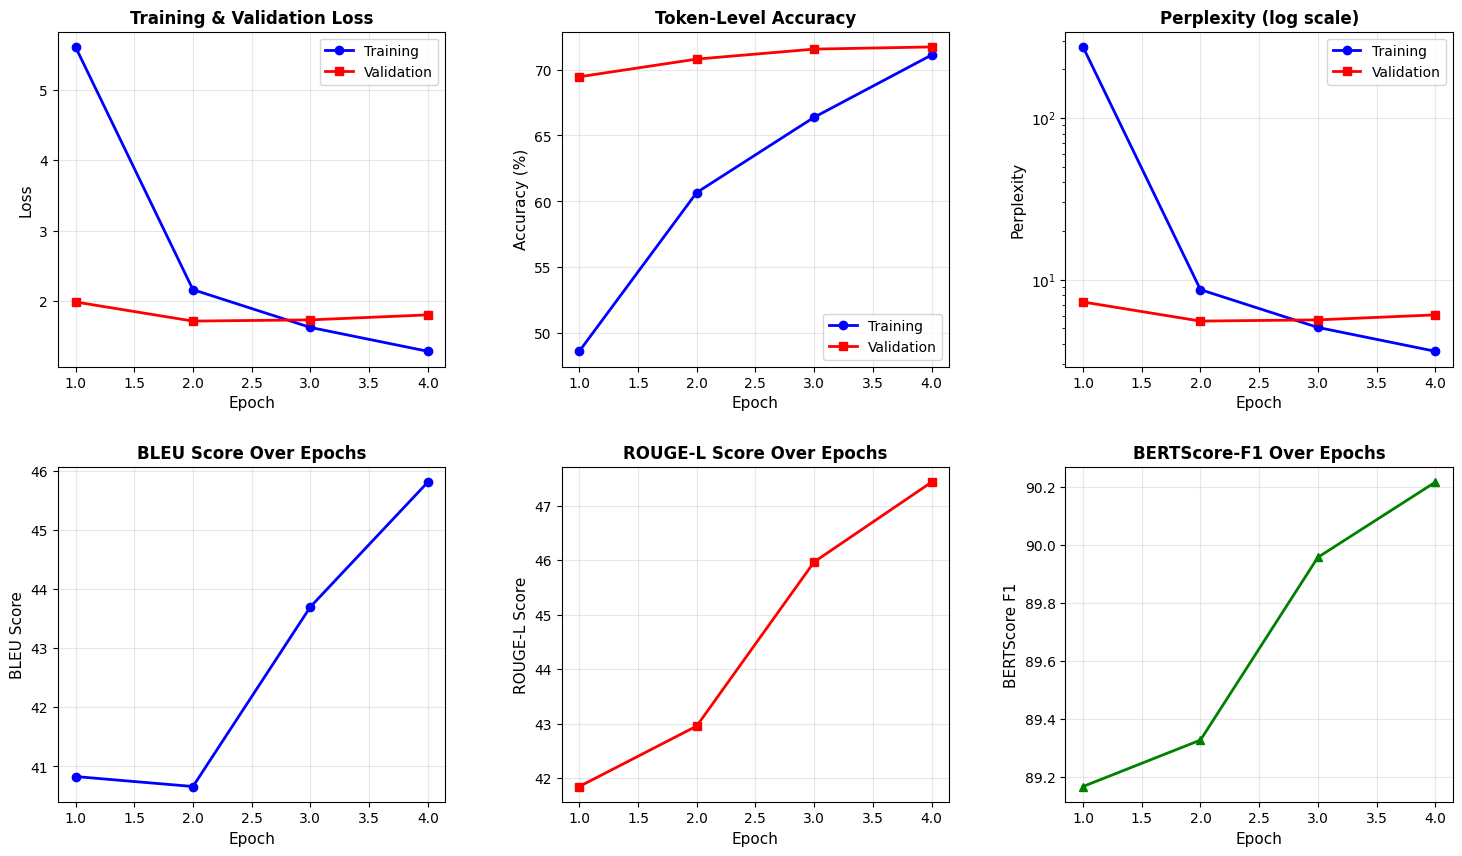


✓ Training completed! Best model saved to best_model.pt

TRAINING SUMMARY
Best validation loss: 1.7143

Final QA Metrics (last computed epoch):
  BLEU:         45.81
  ROUGE-L:      47.44
  BERTScore-F1: 90.22

COMPLETED!


In [ ]:
from model_module.main import main

main(mode='train', use_kg=True)

### eval

Model Configuration:
device                   : cuda
kg_triples_path          : data/knowledge_graph_triples.csv
neo4j_nodes_path         : data/neo4j_nodes.csv
neo4j_rels_path          : data/neo4j_relationships.csv
qa_dataset_path          : data/qa_data.csv
kg_min_confidence        : 0.95
kg_max_hops              : 2
kg_emb_dim               : 300
tokenizer_type           : vit5
vocab_size               : None
vit5_tokenizer_model     : VietAI/vit5-base
use_vncorenlp            : False
vncorenlp_path           : None
use_kg                   : True
vit5_model_name          : VietAI/vit5-base
d_model                  : 768
num_heads                : 12
num_encoder_layers       : 12
num_decoder_layers       : 12
d_ff                     : 3072
gnn_hidden               : 256
gnn_type                 : gcn
gnn_layers               : 2
dropout                  : 0.1
batch_size               : 2
gradient_accumulation_steps: 2
num_epochs               : 5
learning_rate            : 0.0001



Processed 6,379 valid QA pairs
  - Single-hop: 0
  - Multi-hop: 6,379

Example QA pairs:

--- Example 1 (2-hop) ---
ID: qa_4
Question: Vừa qua ngày 4/6 tôi có bị con chó ở nhà cắn xước ngoài da và tôi đã đến trung tâm y tế để tiêm ngừa...
Context: 2. Người đã mắc COVID-19 có phải là đối tượng cần trì hoãn tiêm vắc xin không?
Theo hướng dẫn tạm th...
Answer: Bệnh dại là bệnh nguy hiểm và nếu có chỉ định tiêm phòng vaccine thì cần được ưu...
Entities (9): ['xước', 'tiê', 'tiêm', 'ngừa', 'vaccine']

--- Example 2 (2-hop) ---
ID: qa_7
Question: Mệt mỏi, ngạt mũi có phải triệu chứng bệnh viêm đường hô hấp không?...
Context: 2. Biểu hiện lâm sàng của bệnh
Thời kỳ ủ bệnh: Từ khi nhiễm virus đến khi có biểu hiện bệnh trung bì...
Answer: Các triệu chứng bạn liệt kê ở trên hoàn toàn có thể là những dấu hiệu ban đầu củ...
Entities (5): ['Mệt mỏi', 'ngạt mũi', 'triệu chứng', 'viêm', 'đường hô hấp']

--- Example 3 (2-hop) ---
ID: qa_11
Question: Em đang điều trị ARV được 3 năm và CD4 ổn định ~500 


Computing QA Metrics (BLEU, ROUGE-L, BERTScore)...
Note: Vietnamese baseline not available in bert-score, rescaling disabled
      Scores will be raw values (~0.8-1.0), scaled to 0-100 for display

                    Test Set Performance                    
BLEU         :  40.9692
ROUGE-L      :  43.8156
BERTScore-F1 :  89.4731


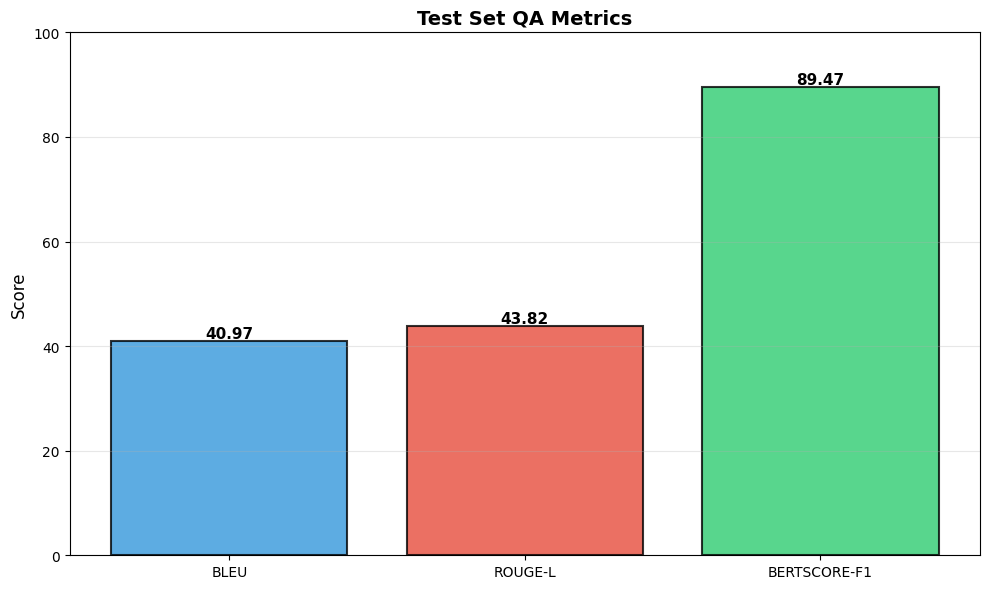


SAMPLE PREDICTIONS

Evaluating model on 5 samples...

--- Sample 1 ---
Question: Trong các triệu chứng của bệnh lý nhiễm trùng ở thận, thì dấu hiệu nào cho thấy nguy cơ nhiễm trùng ...
Entities: triệu chứng, nhiễm trùng, thận, nhiễm trùng huyết
True Answer: Nóng sốt là triệu chứng báo hiệu rất có thể tình trạng nhiễm trùng ở thận đã chu...
Predicted: Trong các triệu chứng của bệnh lý nhiễm trùng ở thận, nếu có nóng sốt thì nên đi...

--- Sample 2 ---
Question: Trong trường hợp áp xe má, nguyên nhân là do răng thì bác sĩ sẽ chỉ định phương pháp điều trị nào?...
Entities: áp xe, răng, chỉ định, điều trị
True Answer: Nếu áp xe má là do răng gây nên, bác sĩ sẽ điều trị tủy hoặc nhổ bỏ răng....
Predicted: Trong trường hợp áp xe má, bác sĩ chỉ định điều trị tủy hoặc nhổ bỏ răng....

--- Sample 3 ---
Question: Biến chứng nghiêm trọng nào có thể xảy ra nếu lichen xơ hóa xuất hiện ở bộ phận sinh dục?...
Entities: Biến chứng, lichen xơ hóa, bộ phận, sinh dục
True Answer: Ung thư tế bào vảy....


In [ ]:
from model_module.main import main

main(mode='eval', use_kg=True)

### interactive

In [ ]:
from model_module.main import main

main(mode="interactive")

Model Configuration:
device                   : cuda
kg_triples_path          : data/knowledge_graph_triples.csv
neo4j_nodes_path         : data/neo4j_nodes.csv
neo4j_rels_path          : data/neo4j_relationships.csv
qa_dataset_path          : data/qa_data.csv
kg_min_confidence        : 0.95
kg_max_hops              : 2
kg_emb_dim               : 300
tokenizer_type           : vit5
vocab_size               : None
max_seq_len              : 128
vit5_tokenizer_model     : VietAI/vit5-base
use_vncorenlp            : False
vncorenlp_path           : None
use_kg                   : True
vit5_model_name          : VietAI/vit5-base
d_model                  : 768
num_heads                : 12
num_encoder_layers       : 12
num_decoder_layers       : 12
d_ff                     : 3072
gnn_hidden               : 256
gnn_type                 : gcn
gnn_layers               : 2
dropout                  : 0.1
batch_size               : 8
num_epochs               : 12
learning_rate            : 0.0001

Processing QA: 100%|██████████| 6379/6379 [00:00<00:00, 11705.36it/s]



Processed 6,379 valid QA pairs
  - Single-hop: 0
  - Multi-hop: 6,379

Example QA pairs:

--- Example 1 (2-hop) ---
ID: qa_4
Question: Vừa qua ngày 4/6 tôi có bị con chó ở nhà cắn xước ngoài da và tôi đã đến trung tâm y tế để tiêm ngừa...
Context: 2. Người đã mắc COVID-19 có phải là đối tượng cần trì hoãn tiêm vắc xin không?
Theo hướng dẫn tạm th...
Answer: Bệnh dại là bệnh nguy hiểm và nếu có chỉ định tiêm phòng vaccine thì cần được ưu...
Entities (9): ['xước', 'tiê', 'tiêm', 'ngừa', 'vaccine']

--- Example 2 (2-hop) ---
ID: qa_7
Question: Mệt mỏi, ngạt mũi có phải triệu chứng bệnh viêm đường hô hấp không?...
Context: 2. Biểu hiện lâm sàng của bệnh
Thời kỳ ủ bệnh: Từ khi nhiễm virus đến khi có biểu hiện bệnh trung bì...
Answer: Các triệu chứng bạn liệt kê ở trên hoàn toàn có thể là những dấu hiệu ban đầu củ...
Entities (5): ['Mệt mỏi', 'ngạt mũi', 'triệu chứng', 'viêm', 'đường hô hấp']

--- Example 3 (2-hop) ---
ID: qa_11
Question: Em đang điều trị ARV được 3 năm và CD4 ổn định ~500 

## Prepare for Huggingface

In [6]:
# ============================================================================
# CELL 1: Import và Setup
# ============================================================================
import torch
import json
import os
import shutil
from pathlib import Path
from transformers import T5Config, T5Tokenizer

# Đường dẫn checkpoint và output
CHECKPOINT_PATH = "best_model.pt"  # Đường dẫn đến best_model.pt của bạn
OUTPUT_DIR = "./hf_model_output"   # Thư mục output
BASE_MODEL = "VietAI/vit5-base"    # Base model ViT5

In [7]:
# ============================================================================
# CELL 2: Load Checkpoint và Extract Info
# ============================================================================
print(f"\n[1/6] Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)

# Extract thông tin
model_state_dict = checkpoint['model_state_dict']
config_dict = checkpoint.get('config_dict', {})
model_arch = checkpoint.get('model_architecture', {})
tokenizer_info = checkpoint.get('tokenizer_info', {})
use_kg = checkpoint.get('use_kg', True)

print("✓ Checkpoint loaded")
print(f"  - use_kg: {use_kg}")
print(f"  - Architecture: {model_arch}")
print(f"  - Best epoch: {checkpoint.get('epoch', 'N/A')}")
print(f"  - Best val_loss: {checkpoint.get('val_loss', 'N/A'):.4f}")


[1/6] Loading checkpoint from best_model.pt...
✓ Checkpoint loaded
  - use_kg: True
  - Architecture: {'vit5_model_name': 'VietAI/vit5-base', 'kg_node_features': 300, 'gnn_hidden': 256, 'gnn_type': 'gcn', 'gnn_layers': 2, 'dropout': 0.1}
  - Best epoch: 1
  - Best val_loss: 1.7143


In [8]:
# ============================================================================
# CELL 3: Tạo Output Directory
# ============================================================================
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)
print(f"\n[2/6] Output directory: {output_dir}")
print("✓ Directory created")


[2/6] Output directory: hf_model_output
✓ Directory created


In [9]:
# ============================================================================
# CELL 4: Load Base Config và Tạo config.json
# ============================================================================
print(f"\n[3/6] Loading base T5 config from {BASE_MODEL}...")
base_config = T5Config.from_pretrained(BASE_MODEL)

# Tạo HuggingFace config
hf_config = {
    "architectures": ["KGEnhancedViT5"],
    "model_type": "t5",
    "d_model": base_config.d_model,
    "d_ff": base_config.d_ff,
    "d_kv": base_config.d_kv,
    "num_heads": base_config.num_heads,
    "num_decoder_layers": base_config.num_decoder_layers,
    "num_layers": base_config.num_layers,
    "vocab_size": base_config.vocab_size,
    "pad_token_id": base_config.pad_token_id,
    "eos_token_id": base_config.eos_token_id,
    "decoder_start_token_id": base_config.decoder_start_token_id,
    "dropout_rate": model_arch.get('dropout', 0.1),
    "layer_norm_epsilon": base_config.layer_norm_epsilon,
    "initializer_factor": base_config.initializer_factor,
    "feed_forward_proj": base_config.feed_forward_proj,
    "dense_act_fn": base_config.dense_act_fn,
    "is_encoder_decoder": True,
    "is_gated_act": False,
    "use_cache": True,
    "n_positions": base_config.n_positions,
    "relative_attention_num_buckets": base_config.relative_attention_num_buckets,
    "relative_attention_max_distance": base_config.relative_attention_max_distance,
    "output_past": True,
    "classifier_dropout": 0.0,
    "dtype": "float32",
    "transformers_version": base_config.transformers_version,

    # Custom fields cho KG enhancement
    "use_kg": use_kg,
    "kg_node_features": model_arch.get('kg_node_features', 300),
    "gnn_hidden": model_arch.get('gnn_hidden', 256),
    "gnn_type": model_arch.get('gnn_type', 'gcn'),
    "gnn_layers": model_arch.get('gnn_layers', 2),
}

# Save config.json
config_path = output_dir / "config.json"
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(hf_config, f, indent=2, ensure_ascii=False)
print(f"✓ Saved config.json")


[3/6] Loading base T5 config from VietAI/vit5-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

✓ Saved config.json


In [11]:
# ============================================================================
# CELL 5: Convert và Save Model Weights (FIXED)
# ============================================================================
print(f"\n[4/6] Converting model weights...")

# Convert state dict keys (remove 't5_model.' prefix nếu có)
hf_state_dict = {}
for key, value in model_state_dict.items():
    if key.startswith('t5_model.'):
        # Remove prefix để khớp với HuggingFace format
        new_key = key.replace('t5_model.', '')
        hf_state_dict[new_key] = value
    else:
        hf_state_dict[key] = value

# Fix shared embeddings issue (T5 shares weights between encoder/decoder/lm_head)
# Clone shared tensors để tránh lỗi safetensors
shared_keys = ['shared.weight', 'encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight']
shared_weight = None

# Tìm shared weight (thường là 'shared.weight' hoặc 't5_model.shared.weight')
for key in ['shared.weight', 't5_model.shared.weight']:
    if key in model_state_dict:
        shared_weight = model_state_dict[key].clone()  # Clone để tạo bản copy riêng
        break

if shared_weight is not None:
    # Clone cho các layer cần thiết
    for key in shared_keys:
        if key in hf_state_dict:
            hf_state_dict[key] = shared_weight.clone()  # Clone riêng cho mỗi key
            print(f"  Fixed shared weight: {key}")

print(f"  Total parameters: {sum(p.numel() for p in hf_state_dict.values()):,}")

# Try safetensors first (preferred)
try:
    from safetensors.torch import save_file
    safetensors_path = output_dir / "model.safetensors"
    save_file(hf_state_dict, safetensors_path)
    print(f"✓ Saved model.safetensors")
except Exception as e:
    print(f"⚠ safetensors error: {e}")
    print("  Falling back to pytorch_model.bin...")
    pytorch_path = output_dir / "pytorch_model.bin"
    torch.save(hf_state_dict, pytorch_path)
    print(f"✓ Saved pytorch_model.bin")


[4/6] Converting model weights...
  Fixed shared weight: shared.weight
  Fixed shared weight: encoder.embed_tokens.weight
  Fixed shared weight: decoder.embed_tokens.weight
  Fixed shared weight: lm_head.weight
  Total parameters: 312,346,113
✓ Saved model.safetensors


In [12]:
# ============================================================================
# CELL 6: Copy Tokenizer Files
# ============================================================================
print(f"\n[5/6] Copying tokenizer files from {BASE_MODEL}...")
tokenizer = T5Tokenizer.from_pretrained(BASE_MODEL)
tokenizer.save_pretrained(output_dir)
print(f"✓ Tokenizer files saved")


[5/6] Copying tokenizer files from VietAI/vit5-base...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/820k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


✓ Tokenizer files saved


In [13]:
# ============================================================================
# CELL 7: Copy modeling_vit5_kg.py và Tạo generation_config.json
# ============================================================================
print(f"\n[6/6] Copying modeling file and creating generation config...")

# Copy modeling_vit5_kg.py
modeling_file = Path("hf_space/modeling_vit5_kg.py")
if modeling_file.exists():
    shutil.copy2(modeling_file, output_dir / "modeling_vit5_kg.py")
    print(f"✓ Copied modeling_vit5_kg.py")
else:
    print(f"⚠ modeling_vit5_kg.py not found at {modeling_file}")

# Tạo generation_config.json
generation_config = {
    "do_sample": False,
    "num_beams": 1,
    "repetition_penalty": 1.2,
    "temperature": 1.0,
    "max_length": 50
}
gen_config_path = output_dir / "generation_config.json"
with open(gen_config_path, 'w', encoding='utf-8') as f:
    json.dump(generation_config, f, indent=2)
print(f"✓ Saved generation_config.json")


[6/6] Copying modeling file and creating generation config...
✓ Copied modeling_vit5_kg.py
✓ Saved generation_config.json
